In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

from sklearn import neighbors, datasets

In [12]:
iris = datasets.load_iris()

X = iris.data[:, :2]
y = iris.target

In [13]:
step_size = 0.01

cmap_light = ListedColormap(["#FFAAAA", "#AAFFAA", "#AAAAFF"])
cmap_bold = ListedColormap(["#FF0000", "#00FF00", "#0000FF"])

In [14]:
neighbors_list = [1, 5]
weights_list = ["uniform", "distance"]

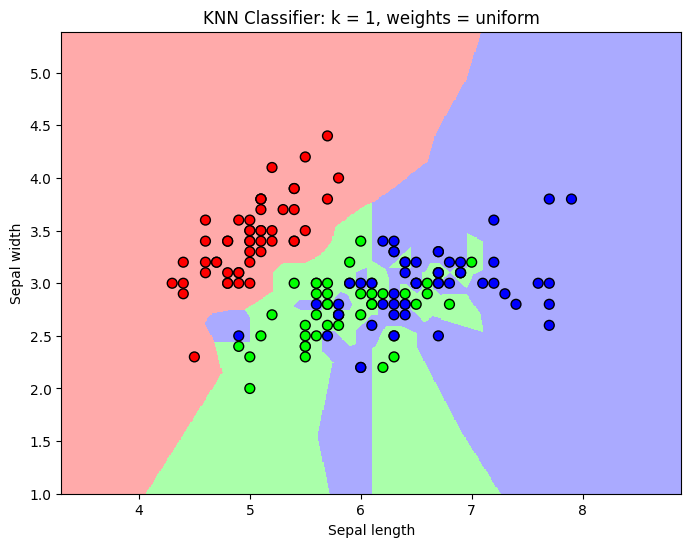

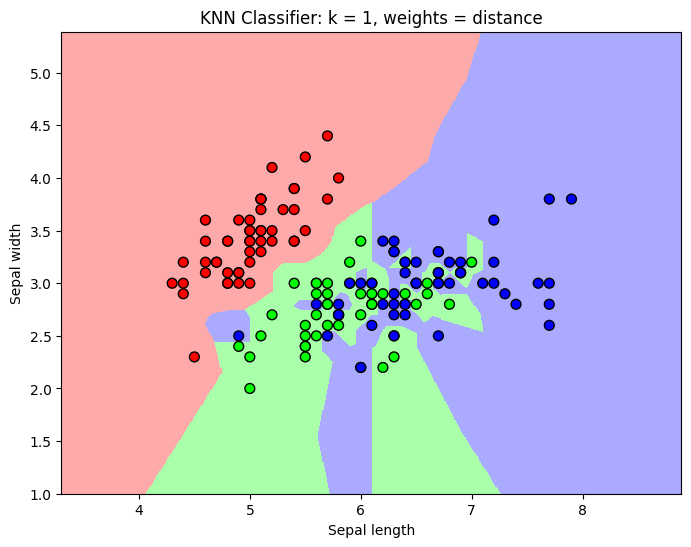

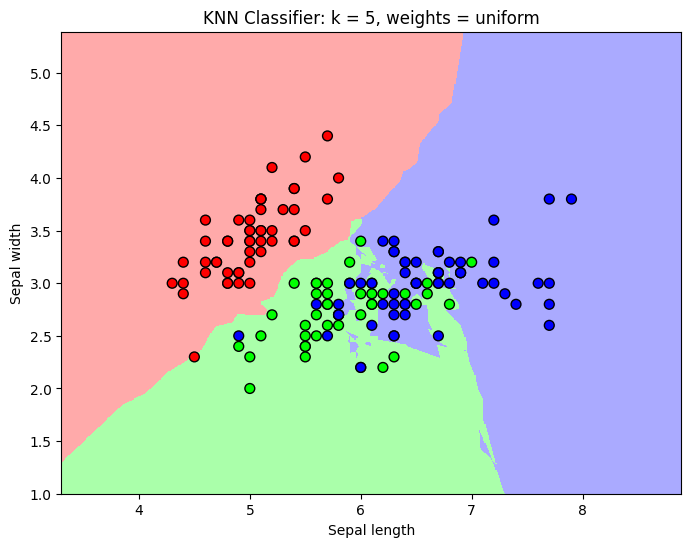

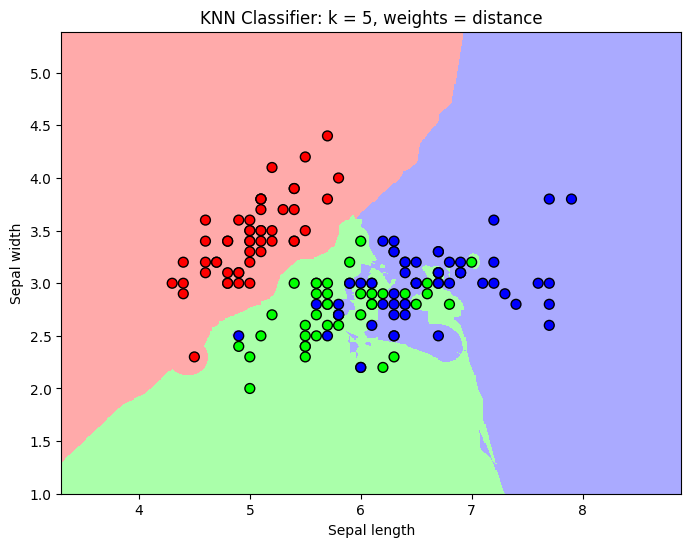

In [15]:
for num_neighbors in neighbors_list:
    for weights in weights_list:

        classifier = neighbors.KNeighborsClassifier(
            n_neighbors=num_neighbors,
            weights=weights
        )

        classifier.fit(X, y)

        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

        x_values, y_values = np.meshgrid(
            np.arange(x_min, x_max, step_size),
            np.arange(y_min, y_max, step_size)
        )

        output = classifier.predict(
            np.c_[x_values.ravel(), y_values.ravel()]
        )

        output = output.reshape(x_values.shape)

        plt.figure(figsize=(8, 6))

        plt.pcolormesh(
            x_values,
            y_values,
            output,
            cmap=cmap_light,
            shading="auto"
        )

        plt.scatter(
            X[:, 0],
            X[:, 1],
            c=y,
            cmap=cmap_bold,
            edgecolor="black",
            s=50
        )

        plt.xlim(x_values.min(), x_values.max())
        plt.ylim(y_values.min(), y_values.max())

        plt.title(
            "KNN Classifier: k = " + str(num_neighbors) + 
            ", weights = " + weights
        )

        plt.xlabel("Sepal length")
        plt.ylabel("Sepal width")

        plt.show()